# OpenScope — Simple-feature oddball vs control (robust schema-discovery version)

This notebook is built around the **same DANDI/NWB access pattern as the working notebook you provided**, but it does **not** hard-code 45°/90° control-trial availability or assume one stimulus-table schema.

## Goals
1. Analyze the known-good example mesoscope session first.
2. Discover the actual NWB stimulus schema and identify the **simple-feature oddball** and its appropriate **control** from the data.
3. Compute all-neuron population peri-stimulus ΔF/F for oddball and control.
4. Repeat across every compatible session in DANDI:001768.
5. Compute an equal-session grand average and save QC tables.

## Important safeguard
A session is **never forced** to have both 45° and 90° matched controls. The classifier first uses explicit semantic fields (`Trial_Type`, `Block_Type`, etc.) when available, then uses orientation/contrast/temporal-frequency parameters only as a fallback. It reports exactly what it selected.

The analysis will skip incompatible sessions with a QC reason rather than crashing the entire run.

In [ ]:
%pip -q install "dandi>=0.70" pynwb h5py remfile pandas numpy matplotlib tqdm scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.6/409.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.0/122.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.6/366.6 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/

In [ ]:
import re, os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import h5py, remfile
from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO

warnings.filterwarnings("ignore")

DANDISET="001768"
VERSION="draft"

# Known-good example session from the working notebook
MOUSE="832700"
DATE_TOKEN="20260129"

PRE=1.0
POST=3.0
REL=np.linspace(-PRE, POST, 201)

# A condition only needs this many usable presentations.
MIN_TRIALS=3

print("Ready.")

Ready.


## 1. Open the known-good example session

In [ ]:
client=DandiAPIClient()
ds=client.get_dandiset(DANDISET, version_id=VERSION)
assets=[a for a in ds.get_assets() if a.path.endswith(".nwb")]

matches=[
    a for a in assets
    if MOUSE in a.path and DATE_TOKEN in re.sub(r"[-_:T]","",a.path)
]
if not matches:
    matches=[a for a in assets if MOUSE in a.path]
if not matches:
    raise RuntimeError("Known-good example-session NWB was not found.")

asset=matches[0]
url=asset.get_content_url(follow_redirects=1, strip_query=True)
rf=remfile.File(url)
hf=h5py.File(rf,"r")
io=NWBHDF5IO(file=hf,mode="r",load_namespaces=True)
nwb=io.read()

print("Opened:",asset.path)
print("session_id:",nwb.session_id)
print("processing:",list(nwb.processing.keys()))
print("interval tables:",list(nwb.intervals.keys()))

Opened: sub-832700/sub-832700_ses-multiplane-ophys-832700-2026-01-29-11-18-09_ophys.nwb
session_id: multiplane-ophys_832700_2026-01-29_11-18-09
processing: ['VISl_4', 'VISl_5', 'VISl_6', 'VISl_7', 'VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'eye_tracking', 'running', 'stimulus']
interval tables: ['Control block 1_presentations', 'Control block 2_presentations', 'Control block 3_presentations', 'Control block 4_presentations', 'RF mapping_presentations', 'Sensory-motor mismatch block_presentations', 'Zebra_presentations', 'spontaneous_presentations']


## 2. Inspect the *actual* stimulus schema

This cell is intentionally verbose. It shows every interval table, row count, columns, and representative categorical values. That makes the condition definition auditable.

In [ ]:
def norm(x):
    return re.sub(r"[^a-z0-9]+","",str(x).lower())

def safe_df(table):
    try:
        return table.to_dataframe()
    except Exception:
        return None

def stimulus_inventory(nwb, verbose=True):
    out=[]
    for name,tab in nwb.intervals.items():
        df=safe_df(tab)
        if df is None or len(df)==0 or "start_time" not in df.columns:
            continue
        rec={"name":name,"df":df,"n":len(df)}
        out.append(rec)
        if verbose:
            print("\n"+"="*80)
            print("TABLE:",name,"| n =",len(df))
            print("COLUMNS:",list(df.columns))
            for c in df.columns:
                if c in ("start_time","stop_time"):
                    continue
                s=df[c]
                try:
                    vals=s.dropna().unique()
                    if len(vals)<=20:
                        print(" ",c,":",vals[:20])
                except Exception:
                    pass
    return out

inventory=stimulus_inventory(nwb,verbose=True)


TABLE: Control block 1_presentations | n = 1088
COLUMNS: ['start_time', 'stop_time', 'stim_name', 'stim_type', 'stim_block', 'Orientation', 'SpatialFrequency', 'TemporalFrequency', 'contrast', 'phase', 'DiameterX', 'DiameterY', 'X', 'Y', 'Duration', 'Delay', 'BlockNumber', 'BlockLabel', 'TrialNumber', 'SequenceNumber', 'TrialInSequence', 'TrialType', 'BlockType', 'stim_index', 'timeseries']
  stim_name : ['Control block 1']
  stim_type : ['None or Blank']
  stim_block : ['0.0' '2.0']
  Orientation : ['0.7853981633974483' '4.319689898685966' '1.5707963267948966'
 '2.356194490192345' '0.3926990816987241' '0.0' '3.9269908169872414'
 '4.71238898038469' '3.141592653589793' '2.748893571891069'
 '5.105088062083414' '3.534291735288517' '1.9634954084936207'
 '1.1780972450961724']
  SpatialFrequency : ['0.04']
  TemporalFrequency : ['2.0' '0.0']
  contrast : ['1.0' '0.0']
  phase : ['0.0']
  DiameterX : ['360.0']
  DiameterY : ['360.0']
  X : ['0.0']
  Y : ['0.0']
  Duration : ['0.343']
  Delay

## 3. Robust condition discovery

The classifier works in this order:

**A. Explicit semantic labels.** It searches table names and categorical columns for terms such as `oddball`, `mismatch`, `deviant`, `control`, and `standard`.

**B. Feature parameters.** It discovers orientation-like columns and uses physical feature values only after context has been established.

**C. Matched-feature intersection.** Oddball and control are compared only for physical feature values that actually occur in **both** conditions. This fixes the previous error: the notebook no longer demands that 45° *and* 90° both exist in every control block.

Omission-like or zero-contrast presentations are excluded when the schema exposes them.

In [ ]:
ODD_WORDS=("oddball","mismatch","deviant","unexpected")
CONTROL_WORDS=("control","random","randomized","shuffle","shuffled")
EXCLUDE_CONTROL_WORDS=("sequentialcontrol",)

def candidate_label_columns(df):
    cols=[]
    for c in df.columns:
        nc=norm(c)
        if any(k in nc for k in ("trialtype","blocktype","condition","stimulus","stimtype","trial","block")):
            cols.append(c)
    return cols

def text_blob(name,df):
    pieces=[str(name)]
    for c in candidate_label_columns(df):
        pieces.append(str(c))
        try:
            vals=df[c].dropna().astype(str).unique()
            pieces.extend(vals[:100])
        except Exception:
            pass
    return " ".join(pieces).lower()

def context_score(name,df,kind):
    blob=text_blob(name,df)
    compact=norm(blob)
    if kind=="odd":
        score=sum(5 for w in ODD_WORDS if w in blob)
        if "standardoddball" in compact: score+=12
        if "visualmismatch" in compact: score+=12
        if "control" in blob: score-=8
        return score
    score=sum(5 for w in CONTROL_WORDS if w in blob)
    if "standardcontrol" in compact: score+=12
    if any(w in compact for w in EXCLUDE_CONTROL_WORDS): score-=10
    if "oddball" in blob or "mismatch" in blob: score-=8
    return score

def find_numeric_feature_col(df):
    # Prefer orientation because this is the simple visual feature oddball.
    preferred=["orientation","orientationdeg","ori"]
    for target in preferred:
        for c in df.columns:
            if target==norm(c) or target in norm(c):
                vals=pd.to_numeric(df[c],errors="coerce")
                if vals.notna().sum()>0:
                    return c
    return None

def exclude_nonvisual_events(df):
    keep=np.ones(len(df),dtype=bool)

    # Explicit omission/halt labels
    for c in candidate_label_columns(df):
        s=df[c].astype(str).str.lower()
        keep &= ~s.str.contains("omission|omit|halt",regex=True,na=False).to_numpy()

    # Zero contrast is not a normal visual feature presentation
    for c in df.columns:
        if "contrast" in norm(c):
            x=pd.to_numeric(df[c],errors="coerce").to_numpy(float)
            keep &= (~np.isfinite(x)) | (x>0)

    return df.loc[keep].copy()

def discover_conditions(nwb, verbose=True):
    inv=stimulus_inventory(nwb,verbose=False)
    if not inv:
        return None

    odd_rank=sorted(
        [(context_score(x["name"],x["df"],"odd"),x) for x in inv],
        key=lambda z:z[0],reverse=True
    )
    ctl_rank=sorted(
        [(context_score(x["name"],x["df"],"control"),x) for x in inv],
        key=lambda z:z[0],reverse=True
    )

    if not odd_rank or odd_rank[0][0]<=0:
        return None
    if not ctl_rank or ctl_rank[0][0]<=0:
        return None

    odd_info=odd_rank[0][1]
    ctl_info=ctl_rank[0][1]

    if odd_info["name"]==ctl_info["name"]:
        alternatives=[x for s,x in ctl_rank if s>0 and x["name"]!=odd_info["name"]]
        if not alternatives:
            return None
        ctl_info=alternatives[0]

    odd_df=exclude_nonvisual_events(odd_info["df"])
    ctl_df=exclude_nonvisual_events(ctl_info["df"])

    odd_feature=find_numeric_feature_col(odd_df)
    ctl_feature=find_numeric_feature_col(ctl_df)
    if odd_feature is None or ctl_feature is None:
        return None

    odd_vals=pd.to_numeric(odd_df[odd_feature],errors="coerce")
    ctl_vals=pd.to_numeric(ctl_df[ctl_feature],errors="coerce")

    odd_unique=np.array(sorted(odd_vals.dropna().unique()),dtype=float)
    ctl_unique=np.array(sorted(ctl_vals.dropna().unique()),dtype=float)

    # Match numerical orientations with tolerance.
    common=[]
    for v in odd_unique:
        if np.any(np.isclose(ctl_unique,v,atol=1e-6)):
            common.append(float(v))

    if not common:
        return None

    # Identify which common values are genuinely rare in oddball context.
    # This avoids treating the repeated standard as the "oddball".
    counts=odd_vals.value_counts()
    if len(counts)>1:
        max_count=counts.max()
        rare=[v for v in common if counts.get(v,0) < max_count]
    else:
        rare=[]

    # Prefer explicitly expected simple-feature orientations when they truly
    # exist, but never require both.
    preferred=[v for v in rare if np.isclose(v,45) or np.isclose(v,90)]
    matched_features=preferred if preferred else rare

    if not matched_features:
        # Semantic oddball tables can sometimes contain only deviants. In that
        # case all common values are legitimate matched candidates.
        matched_features=common

    # Keep only features with enough presentations in both contexts.
    final=[]
    counts_qc=[]
    for v in matched_features:
        no=int(np.isclose(odd_vals.to_numpy(float),v,atol=1e-6,equal_nan=False).sum())
        nc=int(np.isclose(ctl_vals.to_numpy(float),v,atol=1e-6,equal_nan=False).sum())
        counts_qc.append((v,no,nc))
        if no>=MIN_TRIALS and nc>=MIN_TRIALS:
            final.append(v)

    if verbose:
        print("Oddball-context table:",odd_info["name"])
        print("Control-context table:",ctl_info["name"])
        print("Feature columns:",odd_feature,"/",ctl_feature)
        print("Common feature values:",common)
        print("Candidate oddball features:",matched_features)
        print("Counts (feature, oddball, control):",counts_qc)
        print("Features retained:",final)

    if not final:
        return None

    return {
        "odd_name":odd_info["name"],
        "control_name":ctl_info["name"],
        "odd_df":odd_df,
        "control_df":ctl_df,
        "odd_feature":odd_feature,
        "control_feature":ctl_feature,
        "features":final,
        "counts":counts_qc
    }

cond=discover_conditions(nwb,verbose=True)
if cond is None:
    raise RuntimeError(
        "The example session does not expose a safely matchable simple-feature "
        "oddball/control pair under the available NWB schema. See the inventory above."
    )

Oddball-context table: Sensory-motor mismatch block_presentations
Control-context table: Control block 1_presentations
Feature columns: Orientation / Orientation
Common feature values: [0.0, 0.7853981633974483, 1.5707963267948966]
Candidate oddball features: [0.7853981633974483, 1.5707963267948966]
Counts (feature, oddball, control): [(0.7853981633974483, 35, 68), (1.5707963267948966, 35, 68)]
Features retained: [0.7853981633974483, 1.5707963267948966]


## 4. Find ΔF/F and compute peri-stimulus responses

In [ ]:
def get_times(ts):
    # EXACT timebase accessor from the user's known-working movie/PSTH notebook.
    if getattr(ts, "timestamps", None) is not None:
        return np.asarray(ts.timestamps[:], float)
    if getattr(ts, "rate", None) is not None and getattr(ts, "starting_time", None) is not None:
        return float(ts.starting_time) + np.arange(ts.data.shape[0]) / float(ts.rate)
    return None

def find_dff(module):
    # IMPORTANT: this is intentionally the same discovery logic as the
    # known-working notebook. Do NOT return a container merely because its
    # interface is named "dff_timeseries"; we need the actual object with .data
    # and timestamps/rate (usually a RoiResponseSeries).
    for name, obj in module.data_interfaces.items():
        txt = (
            name + " " +
            str(getattr(obj, "name", "")) + " " +
            str(getattr(obj, "description", ""))
        ).lower()

        if ("dff" in txt or "df/f" in txt) and hasattr(obj, "data"):
            return name, obj

        if hasattr(obj, "roi_response_series"):
            for sn, s in obj.roi_response_series.items():
                txt2 = (name + " " + sn).lower()
                if "dff" in txt2 or "df/f" in txt2:
                    return name + "/" + sn, s

    return None, None

def time_by_roi(dff):
    t = get_times(dff)
    if t is None:
        raise RuntimeError(
            "The actual dF/F RoiResponseSeries has no readable timestamps/rate."
        )

    raw = np.asarray(dff.data[:], dtype=np.float32)

    if raw.ndim != 2:
        raise RuntimeError(f"Expected 2-D dF/F; got {raw.shape}")

    if raw.shape[0] == len(t):
        X = raw
    elif raw.shape[1] == len(t):
        X = raw.T
    else:
        raise RuntimeError(
            f"Neither dF/F dimension {raw.shape} matches {len(t)} timestamps."
        )

    return t, X

def feature_onsets(df, col, value):
    x = pd.to_numeric(df[col], errors="coerce").to_numpy(float)
    keep = np.isclose(x, value, atol=1e-6, equal_nan=False)
    return pd.to_numeric(
        df.loc[keep, "start_time"], errors="coerce"
    ).dropna().to_numpy(float)

def neuron_trial_average(t, X, onsets):
    onsets = np.asarray(onsets, float)
    onsets = onsets[np.isfinite(onsets)]
    onsets = onsets[
        (onsets + REL[0] >= t[0]) &
        (onsets + REL[-1] <= t[-1])
    ]

    if len(onsets) < MIN_TRIALS:
        return None, len(onsets)

    total = np.zeros((len(REL), X.shape[1]), float)
    count = np.zeros_like(total, dtype=np.int32)
    base = REL < 0

    for onset in onsets:
        q = onset + REL
        r = np.clip(np.searchsorted(t, q), 1, len(t)-1)
        l = r - 1

        den = t[r] - t[l]
        den[den == 0] = np.nan
        w = ((q - t[l]) / den)[:, None]

        Y = X[l, :] * (1-w) + X[r, :] * w
        Y -= np.nanmean(Y[base, :], axis=0, keepdims=True)

        ok = np.isfinite(Y)
        total[ok] += Y[ok]
        count[ok] += 1

    A = np.divide(
        total, count,
        out=np.full_like(total, np.nan),
        where=count > 0
    ).T

    good = np.isfinite(A).mean(axis=1) > .9
    return A[good], len(onsets)

def analyze_plane(mod, cond):
    dff_name, dff = find_dff(mod)

    if dff is None:
        return None

    t, X = time_by_roi(dff)

    feature_results = {}

    for v in cond["features"]:
        oo = feature_onsets(
            cond["odd_df"], cond["odd_feature"], v
        )
        cc = feature_onsets(
            cond["control_df"], cond["control_feature"], v
        )

        Po, no = neuron_trial_average(t, X, oo)
        Pc, nc = neuron_trial_average(t, X, cc)

        if Po is None or Pc is None:
            continue

        m = min(len(Po), len(Pc))
        if m == 0:
            continue

        feature_results[v] = (
            Po[:m], Pc[:m], no, nc
        )

    if not feature_results:
        return None

    # Equal weighting across matched physical features.
    odd_feature_pop = []
    ctl_feature_pop = []

    for v, (Po, Pc, no, nc) in feature_results.items():
        odd_feature_pop.append(np.nanmean(Po, axis=0))
        ctl_feature_pop.append(np.nanmean(Pc, axis=0))

    odd = np.nanmean(np.stack(odd_feature_pop), axis=0)
    ctl = np.nanmean(np.stack(ctl_feature_pop), axis=0)

    return {
        "dff_object": dff_name,
        "odd": odd,
        "control": ctl,
        "diff": odd - ctl,
        "features": feature_results,
        "n_rois": int(np.mean([
            min(len(z[0]), len(z[1]))
            for z in feature_results.values()
        ]))
    }


## 5. Example session result

All usable VISp/VISl imaging planes are analyzed. Planes are averaged equally for the session-level population trace.

In [ ]:
# Verify that we are using the same actual dF/F RoiResponseSeries/timebase
# discovery as the known-working notebook BEFORE running the oddball analysis.
plane_names = [
    p for p in nwb.processing.keys()
    if re.match(r"^(VISp|VISl)_\d+$", p)
]
plane_names = sorted(plane_names, key=lambda p: (p != "VISp_0", p))

print("NWB planes:", plane_names)
timebase_ok = []

for p in plane_names:
    dff_name, dff = find_dff(nwb.processing[p])

    if dff is None:
        print(p, "-> no actual dF/F data object found")
        continue

    t_test = get_times(dff)

    if t_test is None:
        print(
            p, "->", dff_name,
            "| type:", type(dff).__name__,
            "| NO TIMEBASE"
        )
        continue

    print(
        p, "->", dff_name,
        "| type:", type(dff).__name__,
        "| shape:", tuple(dff.data.shape),
        "| timestamps:", len(t_test)
    )
    timebase_ok.append(p)

if not timebase_ok:
    raise RuntimeError(
        "No plane passed the known-working dF/F/timebase discovery check."
    )

print("\nTimebase verified for:", timebase_ok)


NWB planes: ['VISp_0', 'VISl_4', 'VISl_5', 'VISl_6', 'VISl_7', 'VISp_1', 'VISp_2', 'VISp_3']
VISp_0 -> dff_timeseries/dff_timeseries | type: RoiResponseSeries | shape: (41007, 399) | timestamps: 41007
VISl_4 -> dff_timeseries/dff_timeseries | type: RoiResponseSeries | shape: (41007, 374) | timestamps: 41007
VISl_5 -> dff_timeseries/dff_timeseries | type: RoiResponseSeries | shape: (41007, 356) | timestamps: 41007
VISl_6 -> dff_timeseries/dff_timeseries | type: RoiResponseSeries | shape: (41007, 124) | timestamps: 41007
VISl_7 -> dff_timeseries/dff_timeseries | type: RoiResponseSeries | shape: (41007, 321) | timestamps: 41007
VISp_1 -> dff_timeseries/dff_timeseries | type: RoiResponseSeries | shape: (41007, 463) | timestamps: 41007
VISp_2 -> dff_timeseries/dff_timeseries | type: RoiResponseSeries | shape: (41007, 70) | timestamps: 41007
VISp_3 -> dff_timeseries/dff_timeseries | type: RoiResponseSeries | shape: (41007, 277) | timestamps: 41007

Timebase verified for: ['VISp_0', 'VISl_4',

In [ ]:
planes=[p for p in nwb.processing if re.match(r"^(VISp|VISl)_\d+$",p)]
plane_results={}

for p in planes:
    try:
        r=analyze_plane(nwb.processing[p],cond)
    except Exception as e:
        print("Skipping",p,":",e)
        r=None
    if r is not None:
        plane_results[p]=r

if not plane_results:
    raise RuntimeError(
        "Condition discovery succeeded, but no imaging plane yielded enough usable trials."
    )

example_odd=np.nanmean(np.stack([r["odd"] for r in plane_results.values()]),axis=0)
example_ctl=np.nanmean(np.stack([r["control"] for r in plane_results.values()]),axis=0)
example_diff=example_odd-example_ctl

print("Valid planes:",list(plane_results))
print("Matched oddball feature(s):",cond["features"])

Valid planes: ['VISl_4', 'VISl_5', 'VISl_6', 'VISl_7', 'VISp_0', 'VISp_1', 'VISp_2', 'VISp_3']
Matched oddball feature(s): [0.7853981633974483, 1.5707963267948966]


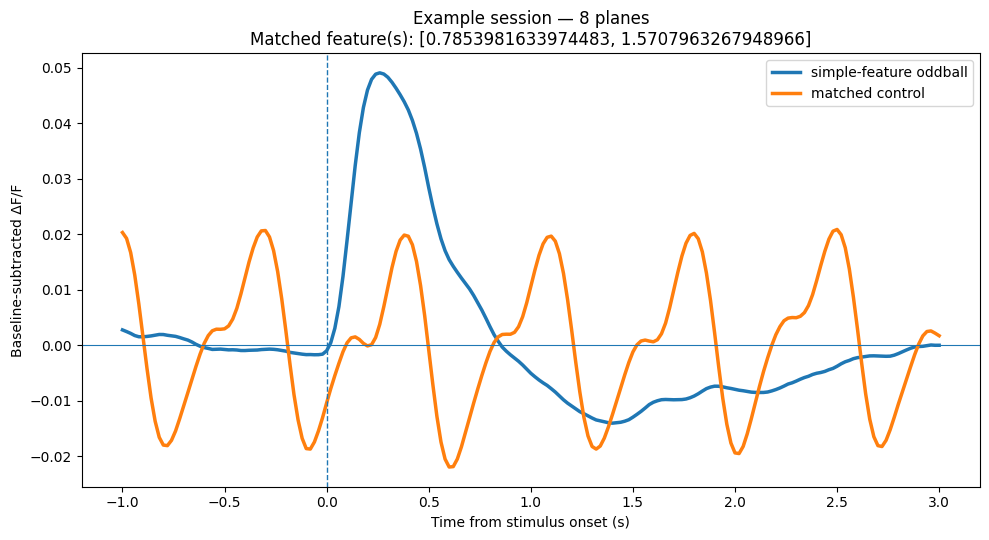

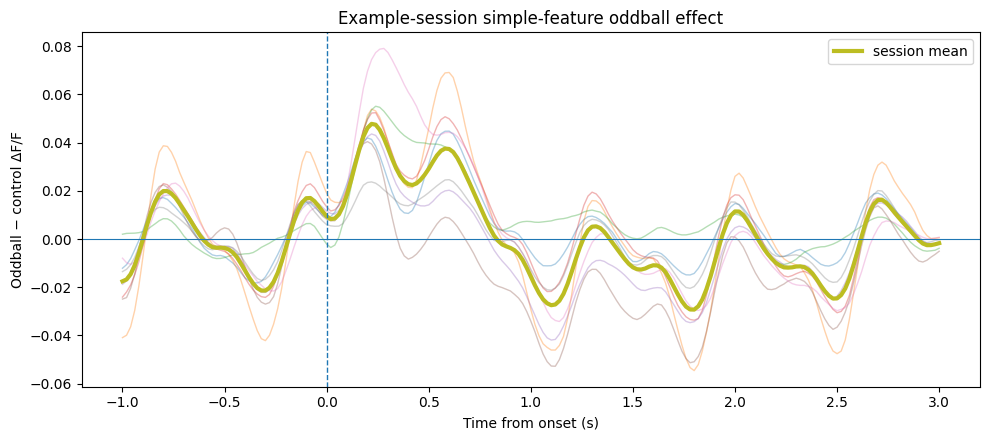

In [ ]:
plt.figure(figsize=(10,5.5))
plt.plot(REL,example_odd,lw=2.5,label="simple-feature oddball")
plt.plot(REL,example_ctl,lw=2.5,label="matched control")
plt.axvline(0,ls="--",lw=1)
plt.axhline(0,lw=.8)
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Baseline-subtracted ΔF/F")
plt.title(f"Example session — {len(plane_results)} planes\nMatched feature(s): {cond['features']}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4.5))
for p,r in plane_results.items():
    plt.plot(REL,r["diff"],alpha=.35,lw=1)
plt.plot(REL,example_diff,lw=3,label="session mean")
plt.axvline(0,ls="--",lw=1)
plt.axhline(0,lw=.8)
plt.xlabel("Time from onset (s)")
plt.ylabel("Oddball − control ΔF/F")
plt.title("Example-session simple-feature oddball effect")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Analyze all compatible sessions in DANDI:001768

The loop below is deliberately fault-tolerant. Every asset gets a QC record. A malformed, incompatible, or non-oddball session is skipped rather than terminating the analysis.

**Grand-average hierarchy:** trials → neurons → feature → plane → session → grand mean.

In [ ]:
def open_nwb_asset(a):
    u=a.get_content_url(follow_redirects=1,strip_query=True)
    rr=remfile.File(u)
    hh=h5py.File(rr,"r")
    ii=NWBHDF5IO(file=hh,mode="r",load_namespaces=True)
    nn=ii.read()
    return rr,hh,ii,nn

def close_nwb(rr,hh,ii):
    try:ii.close()
    except:pass
    try:hh.close()
    except:pass
    try:rr.close()
    except:pass

def analyze_session(nn):
    cc=discover_conditions(nn,verbose=False)
    if cc is None:return None,"no safely matched oddball/control condition"

    pp={}
    for p in nn.processing:
        if not re.match(r"^(VISp|VISl)_\d+$",p):continue
        try:r=analyze_plane(nn.processing[p],cc)
        except Exception:r=None
        if r is not None:pp[p]=r

    if not pp:return None,"condition found but no usable calcium planes"

    odd=np.nanmean(np.stack([r["odd"] for r in pp.values()]),axis=0)
    ctl=np.nanmean(np.stack([r["control"] for r in pp.values()]),axis=0)

    return {
        "odd":odd,"control":ctl,"diff":odd-ctl,
        "n_planes":len(pp),
        "features":cc["features"],
        "odd_table":cc["odd_name"],
        "control_table":cc["control_name"],
        "n_rois_total":sum(r["n_rois"] for r in pp.values())
    },""

all_assets=[a for a in ds.get_assets() if a.path.endswith(".nwb")]
print("NWB assets:",len(all_assets))

NWB assets: 86


In [ ]:
session_results=[]
qc=[]

for a in tqdm(all_assets,desc="All DANDI:001768 NWBs"):
    rr=hh=ii=None
    try:
        rr,hh,ii,nn=open_nwb_asset(a)
        sid=str(nn.session_id)
        subject=str(getattr(getattr(nn,"subject",None),"subject_id",""))
        res,reason=analyze_session(nn)

        if res is None:
            qc.append({
                "asset":a.path,"session_id":sid,"subject_id":subject,
                "included":False,"reason":reason
            })
        else:
            res.update({"asset":a.path,"session_id":sid,"subject_id":subject})
            session_results.append(res)
            qc.append({
                "asset":a.path,"session_id":sid,"subject_id":subject,
                "included":True,"reason":"",
                "features":str(res["features"]),
                "n_planes":res["n_planes"],
                "n_rois_total":res["n_rois_total"],
                "oddball_table":res["odd_table"],
                "control_table":res["control_table"]
            })
    except Exception as e:
        qc.append({
            "asset":a.path,"session_id":"","subject_id":"",
            "included":False,"reason":"ERROR: "+repr(e)[:250]
        })
    finally:
        if ii is not None:close_nwb(rr,hh,ii)
        gc.collect()

qc_df=pd.DataFrame(qc)
display(qc_df)
print("Included:",len(session_results),"of",len(all_assets))

if not session_results:
    raise RuntimeError(
        "No compatible sessions were found. The QC table above shows why; "
        "no condition labels were fabricated to force a result."
    )

All DANDI:001768 NWBs:   0%|          | 0/86 [00:00<?, ?it/s]

,asset,session_id,subject_id,included,reason,features,n_planes,n_rois_total,oddball_table,control_table
0,sub-832700/sub-832700_ses-multiplane-ophys-832...,multiplane-ophys_832700_2026-01-29_11-18-09,832700,True,,"[0.7853981633974483, 1.5707963267948966]",8,2384,Sensory-motor mismatch block_presentations,Control block 1_presentations
1,sub-843001/sub-843001_ses-multiplane-ophys-843...,multiplane-ophys_843001_2026-04-03_11-46-14,843001,True,,[0.0],8,2391,Duration mismatch block_presentations,Control block 1_presentations
2,sub-832700/sub-832700_ses-multiplane-ophys-832...,multiplane-ophys_832700_2026-01-24_12-06-12,832700,True,,"[0.7853981633974483, 1.5707963267948966]",8,2458,Sensory-motor mismatch block_presentations,Control block 1_presentations
3,sub-832700/sub-832700_ses-multiplane-ophys-832...,multiplane-ophys_832700_2026-01-31_11-38-29,832700,True,,"[0.7853981633974483, 1.5707963267948966]",8,2306,Standard mismatch block_presentations,Control block 1_presentations
4,sub-832700/sub-832700_ses-multiplane-ophys-832...,multiplane-ophys_832700_2026-02-12_11-45-55,832700,True,,[0.0],8,2295,Duration mismatch block_presentations,Control block 1_presentations
...,...,...,...,...,...,...,...,...,...,...
81,sub-842971/sub-842971_ses-multiplane-ophys-842...,multiplane-ophys_842971_2026-05-07_09-22-13,842971,True,,"[0.7853981633974483, 1.5707963267948966]",8,2226,Sensory-motor mismatch block_presentations,Control block 1_presentations
82,sub-842971/sub-842971_ses-multiplane-ophys-842...,multiplane-ophys_842971_2026-04-29_09-39-57,842971,True,,"[0.7853981633974483, 1.5707963267948966]",8,2290,Standard mismatch block_presentations,Control block 1_presentations
83,sub-850399/sub-850399_ses-multiplane-ophys-850...,multiplane-ophys_850399_2026-05-27_13-34-48,850399,True,,[0.0],8,2267,Duration mismatch block_presentations,Control block 1_presentations
84,sub-853137/sub-853137_ses-multiplane-ophys-853...,multiplane-ophys_853137_2026-06-25_13-03-30,853137,True,,"[0.7853981633974483, 1.5707963267948966]",8,2118,Standard mismatch block_presentations,Control block 1_presentations


Included: 86 of 86


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=qc_df)

https://docs.google.com/spreadsheets/d/1wfVRYSh775Vy-oKWuDra_MVPeCnVkQdd3kznWQOsSCk/edit#gid=0


## 7. Grand average across sessions

Each included **session contributes one trace**, regardless of ROI count. Shading is SEM across sessions.

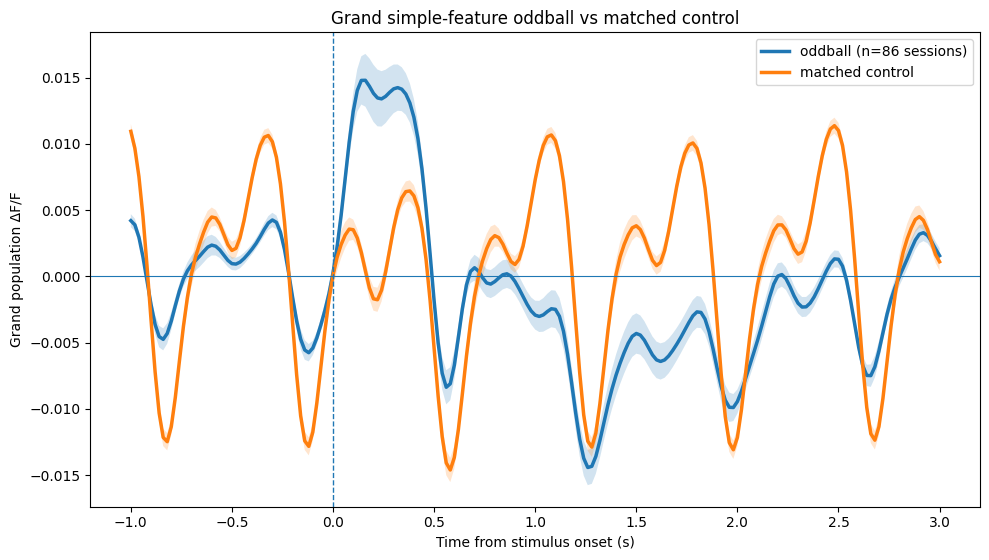

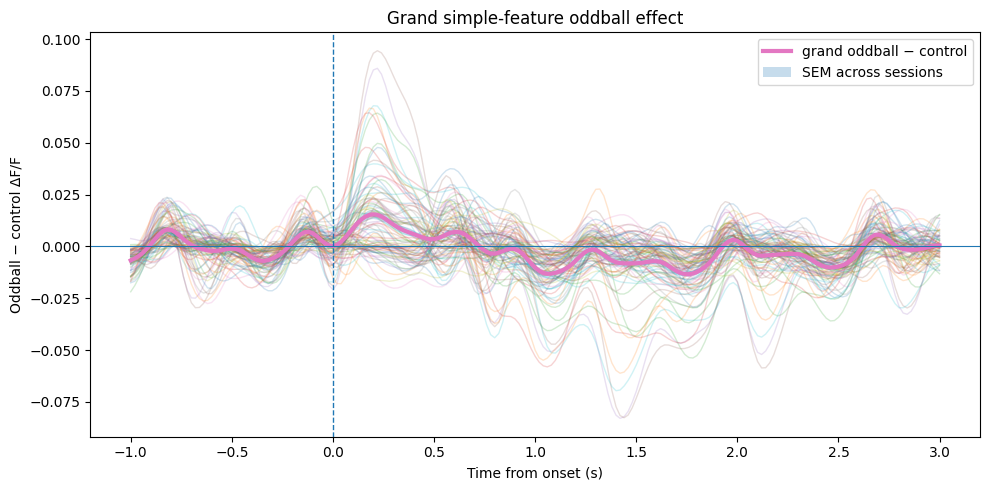

In [ ]:
O=np.stack([r["odd"] for r in session_results])
C=np.stack([r["control"] for r in session_results])
D=O-C

GO=np.nanmean(O,axis=0)
GC=np.nanmean(C,axis=0)
GD=np.nanmean(D,axis=0)

def sem_sessions(A):
    if A.shape[0]<2:return np.zeros(A.shape[1])
    return np.nanstd(A,axis=0,ddof=1)/np.sqrt(A.shape[0])

SO,SC,SD=map(sem_sessions,(O,C,D))

plt.figure(figsize=(10,5.7))
plt.plot(REL,GO,lw=2.5,label=f"oddball (n={len(session_results)} sessions)")
plt.fill_between(REL,GO-SO,GO+SO,alpha=.2)
plt.plot(REL,GC,lw=2.5,label="matched control")
plt.fill_between(REL,GC-SC,GC+SC,alpha=.2)
plt.axvline(0,ls="--",lw=1)
plt.axhline(0,lw=.8)
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Grand population ΔF/F")
plt.title("Grand simple-feature oddball vs matched control")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
for d in D:
    plt.plot(REL,d,alpha=.2,lw=1)
plt.plot(REL,GD,lw=3,label="grand oddball − control")
plt.fill_between(REL,GD-SD,GD+SD,alpha=.25,label="SEM across sessions")
plt.axvline(0,ls="--",lw=1)
plt.axhline(0,lw=.8)
plt.xlabel("Time from onset (s)")
plt.ylabel("Oddball − control ΔF/F")
plt.title("Grand simple-feature oddball effect")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Session summary and saved outputs

In [ ]:
win=(REL>=0)&(REL<=1)
summary=[]

for r,d,o,c in zip(session_results,D,O,C):
    summary.append({
        "session_id":r["session_id"],
        "subject_id":r["subject_id"],
        "features":str(r["features"]),
        "n_planes":r["n_planes"],
        "n_rois_total":r["n_rois_total"],
        "oddball_0_1s":np.nanmean(o[win]),
        "control_0_1s":np.nanmean(c[win]),
        "difference_0_1s":np.nanmean(d[win]),
        "asset":r["asset"]
    })

summary_df=pd.DataFrame(summary)
display(summary_df)

grand_df=pd.DataFrame({
    "time_s":REL,
    "oddball_mean":GO,
    "oddball_sem_sessions":SO,
    "control_mean":GC,
    "control_sem_sessions":SC,
    "difference_mean":GD,
    "difference_sem_sessions":SD,
    "n_sessions":len(session_results)
})

qc_path="/content/simple_feature_oddball_QC.csv"
summary_path="/content/simple_feature_oddball_session_summary.csv"
grand_path="/content/simple_feature_oddball_grand_average.csv"

qc_df.to_csv(qc_path,index=False)
summary_df.to_csv(summary_path,index=False)
grand_df.to_csv(grand_path,index=False)

print(qc_path)
print(summary_path)
print(grand_path)

,session_id,subject_id,features,n_planes,n_rois_total,oddball_0_1s,control_0_1s,difference_0_1s,asset
0,multiplane-ophys_832700_2026-01-29_11-18-09,832700,"[0.7853981633974483, 1.5707963267948966]",8,2384,0.020398,-0.000443,0.020841,sub-832700/sub-832700_ses-multiplane-ophys-832...
1,multiplane-ophys_843001_2026-04-03_11-46-14,843001,[0.0],8,2391,0.000341,0.004499,-0.004158,sub-843001/sub-843001_ses-multiplane-ophys-843...
2,multiplane-ophys_832700_2026-01-24_12-06-12,832700,"[0.7853981633974483, 1.5707963267948966]",8,2458,0.018028,0.002867,0.015161,sub-832700/sub-832700_ses-multiplane-ophys-832...
3,multiplane-ophys_832700_2026-01-31_11-38-29,832700,"[0.7853981633974483, 1.5707963267948966]",8,2306,0.008546,-0.003458,0.012005,sub-832700/sub-832700_ses-multiplane-ophys-832...
4,multiplane-ophys_832700_2026-02-12_11-45-55,832700,[0.0],8,2295,0.000043,-0.001856,0.001899,sub-832700/sub-832700_ses-multiplane-ophys-832...
...,...,...,...,...,...,...,...,...,...
81,multiplane-ophys_842971_2026-05-07_09-22-13,842971,"[0.7853981633974483, 1.5707963267948966]",8,2226,-0.000338,0.001994,-0.002332,sub-842971/sub-842971_ses-multiplane-ophys-842...
82,multiplane-ophys_842971_2026-04-29_09-39-57,842971,"[0.7853981633974483, 1.5707963267948966]",8,2290,0.012928,0.005009,0.007919,sub-842971/sub-842971_ses-multiplane-ophys-842...
83,multiplane-ophys_850399_2026-05-27_13-34-48,850399,[0.0],8,2267,-0.000081,-0.003448,0.003368,sub-850399/sub-850399_ses-multiplane-ophys-850...
84,multiplane-ophys_853137_2026-06-25_13-03-30,853137,"[0.7853981633974483, 1.5707963267948966]",8,2118,0.003655,-0.003603,0.007257,sub-853137/sub-853137_ses-multiplane-ophys-853...


/content/simple_feature_oddball_QC.csv
/content/simple_feature_oddball_session_summary.csv
/content/simple_feature_oddball_grand_average.csv


## Interpretation and statistical caution

A positive oddball-minus-control response means the matched physical feature elicited a larger calcium response in the oddball context than in the control context.

The grand average here weights **sessions equally**, as requested. If the same animal contributes multiple sessions, those sessions are not independent biological replicates. A subsequent inferential analysis should aggregate repeated sessions within mouse (or use a hierarchical model) before testing a population-level hypothesis.

### Data provenance
- OpenScope Community Predictive Processing: https://allenneuraldynamics.github.io/openscope-community-predictive-processing/
- Mesoscope Dandiset: https://dandiarchive.org/dandiset/001768

In [ ]:
try: io.close()
except: pass
try: hf.close()
except: pass
try: rf.close()
except: pass
try: client.close()
except: pass
print("Finished.")